In [1]:
# ==============================================================
# master : 가상의 신호를 생성하여 Worker에게 전송하고,
#          Worker로부터 FFT 결과를 받아 처리 시간을 확인
# ==============================================================

In [1]:
# import
import socket  # TCP 통신을 위한 소켓 라이브러리
import numpy as np
import time    # 시간 측정
import matplotlib.pyplot as plt

In [2]:
# 서버 설정
HOST = "localhost"    # 마스터 서버 주소
PORT = 9999           # 통신 포트

In [3]:
# 신호 생성
signal_length = 30000   # 데이터 길이 (샘플개수)

# 정규분포 기반 랜덤 신호 생성
signal = np.random.randn(signal_length).astype(np.float32)

Master : Worker 접속 대기 중...
master : worker 접속됨 - 주소: ('127.0.0.1', 52876)
master : 신호 전송 시작
master : 신호 전송 완료, 결과 대기 중......
master : FFT 결과 수신 완료 (길이 : 30000)
[왕복 처리 시간] 0.005996 초


C:\Users\human\AppData\Local\Temp\ipykernel_29116\2290069295.py:56: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\human\AppData\Local\Temp\ipykernel_29116\2290069295.py:56: UserWarning: Glyph 54028 (\N{HANGUL SYLLABLE PA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\human\AppData\Local\Temp\ipykernel_29116\2290069295.py:56: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\human\AppData\Local\Temp\ipykernel_29116\2290069295.py:56: UserWarning: Glyph 51652 (\N{HANGUL SYLLABLE JIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\human\AppData\Local\Temp\ipykernel_29116\2290069295.py:56: UserWarning: Glyph 54253 (\N{HANGUL SYLLABLE POG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\human\AppData\Local\Temp\ipykernel_29116\2290069295.py:56: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from

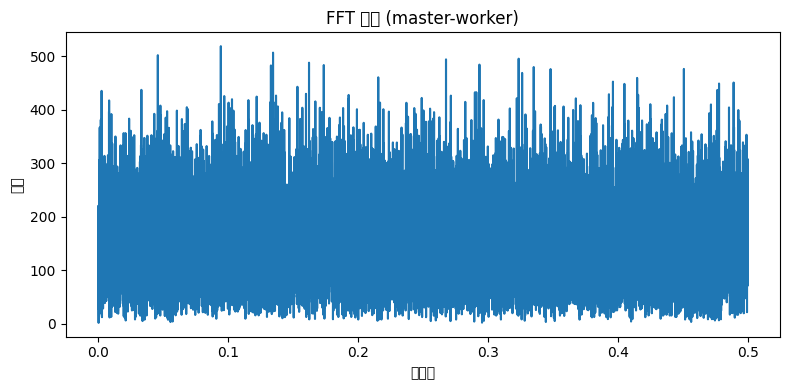

In [4]:
# TCP 서버 시작
with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
    s.bind((HOST, PORT))      # 서버 주소와 포트 연결
    s.listen()                # 클라이언트 접속 대기

    print("Master : Worker 접속 대기 중...")

    conn, addr = s.accept()   # workere 접속시까지 대기

    with conn:
        print(f"master : worker 접속됨 - 주소: {addr}")

        start_time = time.time()   # 처리 시간 측정 시작
        print("master : 신호 전송 시작")

        conn.sendall(signal.tobytes())     # numpy type --> bytes로 변환 후 전송
        print("master : 신호 전송 완료, 결과 대기 중......")

        # 데이터 수신
        expected_bytes = signal_length * 4      # float32 -> 4bytes
        received = b""                          # 수신 데이터 누적

        # tcp는 데이터가 쪼개져서 들어오기 때문에 반복 수신 처리 필요
        while len(received) < expected_bytes:
            chunk = conn.recv(4096)

            if not chunk:          # 데이터 없으면 연결 종료
                break
            received += chunk      # 데이터 누적

        # 데이터 변환
        fft_result = np.frombuffer(received, dtype=np.float32)
        print(f"master : FFT 결과 수신 완료 (길이 : {len(fft_result)})")

        # 처리시간 측정 완료
        end_time = time.time()
        elapsed = end_time - start_time

        print(f"[왕복 처리 시간] {elapsed:.4} 초")

        # 결과 시각화 
        # FFT 결과는 주파수 데이터임
        freqs = np.fft.fftfreq(signal_length, d=1.0)

        plt.figure(figsize=(8,4))

        plt.plot(
            freqs[:signal_length // 2],
            fft_result[:signal_length // 2]
        )

        plt.xlabel('주파수')
        plt.ylabel('진폭')
        plt.title('FFT 결과 (master-worker)')

        plt.tight_layout()
        plt.show()

                  
        

        
        






    